In [1]:
import os
import ast
import math
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 10})
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score
import torch
# Importing neuroimaging package(s)
import pydicom

In [2]:
import sys
sys.path.append('../src/')

%load_ext autoreload
%autoreload 2
# Importing our custom module(s)
import ct
import datasets
import models
import mri
import utils

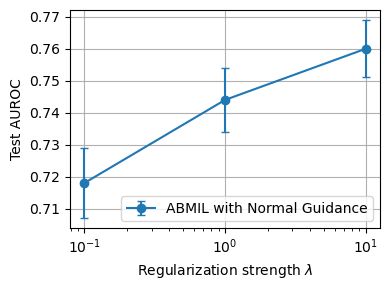

In [24]:
lambdas = [0.1, 1.0, 10.0]
#auroc_means = [0.846, 0.871, 0.877]
#auroc_stds = [0.004, 0.002, 0.001]
auprc_means = [0.718, 0.744, 0.760]
auprc_stds = [0.011, 0.010, 0.009]

fig, ax = plt.subplots(figsize=(4, 3), ncols=1, nrows=1)

#ax.errorbar(lambdas, auroc_means, auroc_stds, capsize=3, color="#1F77B4", label="ABMIL with Normal Guidance", marker="o")
ax.errorbar(lambdas, auprc_means, auprc_stds, capsize=3, color="#1F77B4", label="ABMIL with Normal Guidance", marker="o")
ax.set_xlabel(r"Regularization strength $\lambda$")
ax.set_ylabel("Test AUROC")
ax.set_xscale("log")
ax.legend()
ax.grid()

fig.tight_layout()
fig.savefig("varying_the_regularization_strength_auprc.pdf", bbox_inches="tight")
plt.show()

In [29]:
seed = 3_001
dataset_dir = f"/cluster/tufts/hugheslab/datasets/encoded_RSNA_ICH_full_dataset/ViT_B_16/seed={seed}"

train_data = torch.load(f"{dataset_dir}/train.pt", map_location=torch.device("cpu"))
val_data = torch.load(f"{dataset_dir}/val.pt", map_location=torch.device("cpu"))
test_data = torch.load(f"{dataset_dir}/test.pt", map_location=torch.device("cpu"))

for i, (length, length_y) in enumerate(zip(train_data["lengths"], train_data["lengths_y"])):
    if length != len(length_y):
        train_data["lengths_y"][i] = [0 for _ in range(length)]

for i, (length, length_y) in enumerate(zip(val_data["lengths"], val_data["lengths_y"])):
    if length != len(length_y):
        val_data["lengths_y"][i] = [0 for _ in range(length)]

for i, (length, length_y) in enumerate(zip(test_data["lengths"], test_data["lengths_y"])):
    if length != len(length_y):
        test_data["lengths_y"][i] = [0 for _ in range(length)]

torch.save(train_data, f"{dataset_dir}/train.pt")
torch.save(val_data, f"{dataset_dir}/val.pt")
torch.save(test_data, f"{dataset_dir}/test.pt")


In [3]:
dicom_dir = "/cluster/tufts/hugheslab/datasets/RSNA_ICH"

#with open(f"{dicom_dir}/meta_data.csv", "w") as f:
#    f.write("Patient ID,Study ID,Series ID,Slice ID,z\n")
#    for root, _, files in os.walk(f"{dicom_dir}/stage_2_train"):
#        for name in files:
#            if name.endswith(".dcm"):
#                ds = pydicom.dcmread(os.path.join(root, name), stop_before_pixels=True)
#                f.write(f"{ds.PatientID},{ds.StudyInstanceUID},{ds.SeriesInstanceUID},{ds.SOPInstanceUID},{ds.ImagePositionPatient[2]}\n")

meta_data_df = pd.read_csv(f"{dicom_dir}/meta_data.csv")
stage_2_train_df = pd.read_csv(f"{dicom_dir}/stage_2_train.csv")
stage_2_train_df = stage_2_train_df.drop_duplicates()
stage_2_train_df["Slice ID"] = stage_2_train_df["ID"].str.rsplit("_", n=1).str[0]
stage_2_train_df["Label Type"] = stage_2_train_df["ID"].str.rsplit("_", n=1).str[1].str.capitalize()
stage_2_train_df = stage_2_train_df.pivot(index="Slice ID", columns="Label Type", values="Label").rename_axis(None, axis=1).reset_index()
meta_data_df = pd.merge(meta_data_df, stage_2_train_df, on="Slice ID", how="inner")
print(meta_data_df.shape)
print(len(meta_data_df[["Patient ID", "Series ID"]].value_counts()))
meta_data_df.head()


(752803, 11)
21744


,Patient ID,Study ID,Series ID,Slice ID,z,Any,Epidural,Intraparenchymal,Intraventricular,Subarachnoid,Subdural
0,ID_f15c0eee,ID_30ea2b02d4,ID_0ab5820b2a,ID_000012eaf,77.970825,0,0,0,0,0,0
1,ID_eeaf99e7,ID_134d398b61,ID_5f8484c3e0,ID_000039fa0,62.720940,0,0,0,0,0,0
2,ID_18f2d431,ID_b5c26cda09,ID_203cd6ec46,ID_00005679d,-39.569000,0,0,0,0,0,0
3,ID_ce8a3cd2,ID_974735bf79,ID_3780d48b28,ID_00008ce3c,175.995344,0,0,0,0,0,0
4,ID_d278c67b,ID_8881b1c4b1,ID_84296c3845,ID_0000950d7,157.500000,0,0,0,0,0,0


In [4]:
sorted_full_dataset_df = meta_data_df.sort_values(["Study ID", "z"], ascending=[True, True])
grouped_df = sorted_full_dataset_df.groupby(["Patient ID", "Study ID", "Series ID"]).agg({"Slice ID": list, "z": list, "Any": list}).reset_index()
#grouped_df.to_csv(f"{dicom_dir}/full_dataset_labels.csv", index=False)
print(grouped_df.shape)
grouped_df.head()


(21744, 6)


,Patient ID,Study ID,Series ID,Slice ID,z,Any
0,ID_0002cd41,ID_66929e09d4,ID_e22a5534e6,"[ID_45785016b, ID_37f32aed2, ID_1b9de2922, ID_...","[35.968, 38.484, 41.0, 43.517, 46.033, 48.549,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,ID_00054f3f,ID_8a449ae31b,ID_15c3dd58c7,"[ID_138d275c8, ID_447fa09d9, ID_0f1298f68, ID_...","[71.9000244, 76.9000244, 81.9000244, 86.900024...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,ID_0006d192,ID_25690b4725,ID_4ec55fa0d7,"[ID_c6f9f68c9, ID_520df89aa, ID_b86dc15dd, ID_...","[38.171, 41.921, 45.671, 49.421, 53.171, 56.92...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,ID_00086119,ID_fdde2979b0,ID_caa405a7f2,"[ID_31b14de96, ID_203ef1efe, ID_9ce17ada6, ID_...","[32.955, 35.556, 38.156, 40.757, 43.358, 45.95...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,ID_000e5623,ID_9a4be35b9a,ID_0880626a95,"[ID_0785539ea, ID_30c100dbc, ID_3df0d63c3, ID_...","[272.0, 277.0, 282.0, 287.0, 292.0, 297.0, 302...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [5]:
splits_df = pd.read_csv(f"{dicom_dir}/splits.csv")
print(splits_df.shape)
print(len(splits_df[["bag_name"]].value_counts()))
splits_df.head()


(39750, 2)
1149


,bag_name,split
0,ID_00047d6503,train
1,ID_00047d6503,train
2,ID_00047d6503,train
3,ID_00047d6503,train
4,ID_00047d6503,train


In [6]:
subset_df = meta_data_df[meta_data_df["Study ID"].isin(splits_df.bag_name)]
print(subset_df.shape)
print(len(subset_df[["Study ID"]].value_counts()))
subset_df.head()


(39710, 11)
1149


,Patient ID,Study ID,Series ID,Slice ID,z,Any,Epidural,Intraparenchymal,Intraventricular,Subarachnoid,Subdural
7,ID_df70c823,ID_04ef429610,ID_245e16180c,ID_0000f1657,367.000000,0,0,0,0,0,0
36,ID_40e9e7d3,ID_050fb6fd74,ID_515e22993b,ID_00042829c,24.067000,1,0,0,1,0,0
68,ID_f4a496fe,ID_0bf3cffbe6,ID_3d1e00ebf0,ID_0006a4a73,193.300049,0,0,0,0,0,0
91,ID_4a5cab9b,ID_feac26ebe2,ID_8b77760729,ID_000854890,88.020454,0,0,0,0,0,0
94,ID_d212cb48,ID_059e3f1d01,ID_f15cc986b7,ID_00087a0c0,203.642000,0,0,0,0,0,0


In [7]:
sorted_subset_df = subset_df.sort_values(["Study ID", "z"], ascending=[True, True])
grouped_df = sorted_subset_df.groupby(["Patient ID", "Study ID", "Series ID"]).agg({"Slice ID": list, "z": list, "Any": list}).reset_index()
#grouped_df.to_csv(f"{dicom_dir}/subset_labels.csv", index=False)
print(grouped_df.shape)
grouped_df.head()


(1149, 6)


,Patient ID,Study ID,Series ID,Slice ID,z,Any
0,ID_005f241d,ID_07e2cf7b4b,ID_9559629fea,"[ID_e29b63250, ID_766be7451, ID_b56e447c4, ID_...","[63.879, 66.486, 69.094, 71.701, 74.308, 76.91...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,ID_0075b28c,ID_0373dbdd02,ID_ee6d0ccad3,"[ID_b2e23d464, ID_0d5c28287, ID_3cf464707, ID_...","[38.952644, 41.534897, 44.117146, 46.699394, 4...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,ID_00760731,ID_006a2c59e4,ID_841c387fe1,"[ID_080e55858, ID_ad9ea42be, ID_99ebeb668, ID_...","[5.25, 10.25, 15.25, 20.25, 25.25, 30.25, 35.2...","[0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, ..."
3,ID_00859e11,ID_01f49be39f,ID_79fceb7cda,"[ID_6407b752d, ID_bff0001cf, ID_13305866b, ID_...","[-1.452, 3.713, 8.877, 14.042, 19.206, 24.371,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, ..."
4,ID_00a3b735,ID_065682422f,ID_aedce3287f,"[ID_db255faea, ID_68ba9321f, ID_d304839bb, ID_...","[69.9000244, 74.9000244, 79.9000244, 84.900024...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [3]:
dicom_dir = "/cluster/tufts/hugheslab/datasets/RSNA_ICH"
labels_df = pd.read_csv(f"{dicom_dir}/full_dataset_labels.csv")
columns = ["Slice ID", "z", "Any"]
labels_df[columns] = labels_df[columns].apply(lambda col: col.map(ast.literal_eval))
print(labels_df.shape)
labels_df.head()


(21744, 6)


,Patient ID,Study ID,Series ID,Slice ID,z,Any
0,ID_0002cd41,ID_66929e09d4,ID_e22a5534e6,"[ID_45785016b, ID_37f32aed2, ID_1b9de2922, ID_...","[35.968, 38.484, 41.0, 43.517, 46.033, 48.549,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,ID_00054f3f,ID_8a449ae31b,ID_15c3dd58c7,"[ID_138d275c8, ID_447fa09d9, ID_0f1298f68, ID_...","[71.9000244, 76.9000244, 81.9000244, 86.900024...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,ID_0006d192,ID_25690b4725,ID_4ec55fa0d7,"[ID_c6f9f68c9, ID_520df89aa, ID_b86dc15dd, ID_...","[38.171, 41.921, 45.671, 49.421, 53.171, 56.92...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,ID_00086119,ID_fdde2979b0,ID_caa405a7f2,"[ID_31b14de96, ID_203ef1efe, ID_9ce17ada6, ID_...","[32.955, 35.556, 38.156, 40.757, 43.358, 45.95...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,ID_000e5623,ID_9a4be35b9a,ID_0880626a95,"[ID_0785539ea, ID_30c100dbc, ID_3df0d63c3, ID_...","[272.0, 277.0, 282.0, 287.0, 292.0, 297.0, 302...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [16]:
num_lesions = np.zeros(len(labels_df))
lesion_lengths = []

for row_index, row in labels_df.iterrows():
    
    instance_labels = row["Any"]
    patience = 3
    
    counter = 0
    last_one = False
    k = patience
    
    for i in range(len(instance_labels)):

        if instance_labels[i] == 1.0:

            counter += 1
            last_one = True

            if k != patience:
                counter += patience - k

            k = patience

        else:  

            if last_one:

                if k > 0:
                    k -= 1
                else:
                    num_lesions[row_index] += 1
                    lesion_lengths.append(counter/len(instance_labels))
                    counter = 0
                    last_one = False
                    k = patience

    if counter > 0:
        num_lesions[row_index] += 1
        lesion_lengths.append(counter/len(instance_labels))
        
print(f"mean: {np.mean(lesion_lengths)}")
print(f"median: {np.median(lesion_lengths)}")


mean: 0.3502174730248659
median: 0.34210526315789475


In [19]:
print(f"{np.mean(lesion_lengths):.3f}")
print(f"{np.min(lesion_lengths):.3f}")
for q in np.quantile(lesion_lengths, [0.05, 0.25, 0.50, 0.75, 0.95]):
    print(f"{q:.3f}")
print(f"{np.max(lesion_lengths):.3f}")


0.350
0.017
0.053
0.172
0.342
0.513
0.688
1.000


In [11]:
np.unique(num_lesions, return_counts=True)

(array([0., 1., 2., 3.]), array([12862,  8296,   569,    17]))

(512, 512)


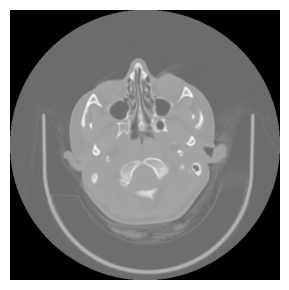

In [13]:
ds = pydicom.dcmread(f"{dicom_dir}/stage_2_train/ID_45785016b.dcm")
print(ds.pixel_array.shape)

fig, ax = plt.subplots(1, 1, figsize=(4, 3))

ax.imshow(ds.pixel_array, cmap="gray")
ax.axis("off")

fig.tight_layout()

plt.show()

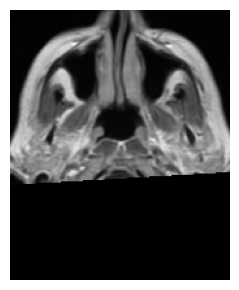

In [34]:
import torch

numpy_dir = "/cluster/tufts/hugheslab/datasets/OASIS-3_CT_numpy"
scan = np.load(f"{numpy_dir}/OAS30001_CT_d2438.npz")["arr_0"]
numpy_dir = "/cluster/tufts/hugheslab/datasets/RSNA_ICH_numpy"
scan = np.load(f"{numpy_dir}/ID_66929e09d4.npz")["arr_0"]
numpy_dir = "/cluster/tufts/hugheslab/datasets/OASIS-3_MRI_numpy"
scan = np.load(f"{numpy_dir}/OAS30001_MR_d0129.npz")["arr_0"]
numpy_dir = "/cluster/tufts/hugheslab/datasets/ADNI1_Complete_1Yr_1.5T_numpy"
scan = np.load(f"{numpy_dir}/002_S_0295__I118671.npz")["arr_0"]
numpy_dir = "/cluster/tufts/hugheslabkp/data_irb_required/KPSC_MRI_800_numpy"
scan = np.load(f"{numpy_dir}/STUDY_0010.npz")["arr_0"]

fig, ax = plt.subplots(1, 1, figsize=(4, 3))

#ax.imshow(torch.tensor(scan).permute(3, 0, 1, 2)[0,0,:,:], cmap="gray")
ax.imshow(torch.rot90(torch.tensor(scan).permute(3, 0, 1, 2)[0,0,:,:], k=1, dims=[-2, -1]), cmap="gray")
ax.axis("off")

fig.tight_layout()

plt.show()

mean: 0.5083903598367323, std: 0.17981148434135166


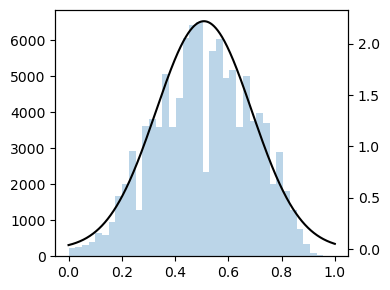

In [10]:
def normal_pdf(x, mu=0.0, sigma=1.0):
    norm_const = 1 / np.sqrt(2.0 * np.pi * sigma**2)
    exp_quad_term = np.exp(-0.5 * ((x - mu) / sigma) ** 2)
    return norm_const * exp_quad_term

series = labels_df.apply(lambda row: [j / len(row.Any) for j, y_ij in enumerate(row.Any) if y_ij == 1.0], axis=1)
values = [item for sublist in series for item in sublist]
mean, std = np.mean(values), np.std(values)
print(f"mean: {mean}, std: {std}")

fig, ax1 = plt.subplots(1, 1, figsize=(4, 3))

ax1.hist(values, alpha=0.3, bins=np.linspace(start=min(values), stop=max(values), num=40), color="#1F77B4")
ax2 = ax1.twinx()
x = np.linspace(start=0, stop=1, num=1_000)
ax2.plot(x, normal_pdf(x, mean, std), color="#000000")

fig.tight_layout()
plt.show()


In [84]:
################################################################################
def print_job(
    alpha, batch_size, criterion, dataset_dir, epochs, embedding_level, 
    experiments_dir, lr, pooling, save, seed, weight_decay
):
    
    model_name = f"alpha={alpha}_criterion={criterion}_lr={lr}_pooling={pooling}_seed={seed}"
    
    if os.path.exists(f"{experiments_dir}/{model_name}.csv"):
        temp_df = pd.read_csv(f"{experiments_dir}/{model_name}.csv")
        if temp_df.shape[0] == epochs:
            return
        
    embedding_level = "--embedding_level " if embedding_level else ""
    save = "--save " if save else ""
    
    command = (
        f"python ../src/oasis-3.py "
        f"--alpha={alpha} "
        f"--batch_size={batch_size} "
        f"--criterion=\"{criterion}\" "
        f"--dataset_dir=\"{dataset_dir}\" "
        f"--epochs={epochs} "
        f"{embedding_level}"
        f"--experiments_dir=\"{experiments_dir}\" "
        f"--lr={lr} "
        f"--model_name=\"{model_name}\" "
        f"--pooling=\"{pooling}\" "
        f"{save}"
        f"--seed={seed} "
        f"--weight_decay={weight_decay}"
    )
    
    print(f"    \'{command}\'")

In [85]:
alphas = [1.0, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 0.0]
alphas = [0.0001]
beta = 0.0
batch_size = 64
criterions = ["GuidedL1"]
dataset_dir = "/cluster/tufts/hugheslab/datasets/encoded_RSNA_ICH_full_dataset/ViT_B_16"
epochs = 1000
#embedding_level = False
embedding_level = True
#experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_ICH_subset_embedding_level=False" 
#experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_ICH_subset_embedding_level=True" 
experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_ICH_full_dataset_embedding_level=True" 
experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_ICH_full_dataset_beta=10.0_embedding_level=True" 
#experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_ICH_full_dataset_beta=1.0_embedding_level=True" 
#experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_ICH_full_dataset_beta=1.0_embedding_level=True_kl=reverse" 
experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_ICH_full_dataset_beta=1.0_embedding_level=True_kl=squared"
#experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_ICH_full_dataset_beta=1.0_embedding_level=True_multi_head=False" 
lrs = [0.1, 0.01, 0.001, 0.0001]
#poolings = ["Max", "Mean", "ABMIL", "SmAP"]
poolings = ["Max", "Mean", "ABMIL", "TransMIL", "SmAP"]
poolings = ["ABMIL"]
#poolings = ["TransMIL"]
save = True
seeds = [1001, 2001, 3001]
weight_decay = 0.0

for alpha, criterion, lr, pooling, seed in itertools.product(alphas, criterions, lrs, poolings, seeds):
    
    temp_dataset_dir = f"{dataset_dir}/seed={seed}"

    print_job(alpha, batch_size, criterion, temp_dataset_dir, epochs, embedding_level, 
              experiments_dir, lr, pooling, save, seed, weight_decay)


    'python ../src/oasis-3.py --alpha=0.0001 --batch_size=64 --criterion="GuidedL1" --dataset_dir="/cluster/tufts/hugheslab/datasets/encoded_RSNA_ICH_full_dataset/ViT_B_16/seed=2001" --epochs=1000 --embedding_level --experiments_dir="/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_ICH_full_dataset_beta=1.0_embedding_level=True_kl=squared" --lr=0.1 --model_name="alpha=0.0001_criterion=GuidedL1_lr=0.1_pooling=ABMIL_seed=2001" --pooling="ABMIL" --save --seed=2001 --weight_decay=0.0'
    'python ../src/oasis-3.py --alpha=0.0001 --batch_size=64 --criterion="GuidedL1" --dataset_dir="/cluster/tufts/hugheslab/datasets/encoded_RSNA_ICH_full_dataset/ViT_B_16/seed=3001" --epochs=1000 --embedding_level --experiments_dir="/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_ICH_full_dataset_beta=1.0_embedding_level=True_kl=squared" --lr=0.1 --model_name="alpha=0.0001_criterion=GuidedL1_lr=0.1_pooling=ABMIL_seed=3001" --pooling="ABMIL" --save --seed=3001 --weight_decay=0.0'
    'pyt

In [27]:
alphas = [1.0, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 0.0]
beta = 0.0
batch_size = 64
criterions = ["GuidedL1"]
dataset_dir = "/cluster/tufts/hugheslab/datasets/encoded_RSNA_ICH/ViT_B_16"
epochs = 1000
#embedding_level = False
embedding_level = True
#experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_ICH_subset_embedding_level=False" 
#experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_ICH_subset_embedding_level=True" 
experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_ICH_full_dataset_embedding_level=True" 
experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_ICH_full_dataset_beta=10.0_embedding_level=True" 
experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_ICH_full_dataset_beta=1.0_embedding_level=True_kl=squared" 
#experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_ICH_full_dataset_beta=1.0_embedding_level=True_kl=reverse" 
#experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_ICH_full_dataset_beta=1.0_embedding_level=True_multi_head=False" 
#experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_ICH_full_dataset_best_possible_instance-level"
#experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_ICH_full_dataset_best_possible_bag-level" 
lrs = [0.1, 0.01, 0.001, 0.0001]
poolings = ["Max", "Mean", "ABMIL", "TransMIL", "SmAP"]
poolings = ["ABMIL"]
save = True
seeds = [1001, 2001, 3001]
weight_decay = 0.0

columns = ["model_name", "seed", "test_auroc", "test_auprc", "test_bal_acc", "test_loss", "test_nll", "train_auroc", "train_auprc", "train_bal_acc", "train_loss", "train_nll", "val_auroc", "val_auprc", "val_bal_acc", "val_loss", "val_nll"]
df = pd.DataFrame(columns=columns)

for alpha, criterion, lr, pooling, seed in itertools.product(alphas, criterions, lrs, poolings, seeds):
    
    model_name = f"alpha={alpha}_criterion={criterion}_lr={lr}_pooling={pooling}_seed={seed}"
    #model_name = f"alpha={alpha}_criterion={criterion}_lr={lr}_seed={seed}"
    
    if os.path.exists(f"{experiments_dir}/{model_name}.csv"):
        temp_df = pd.read_csv(f"{experiments_dir}/{model_name}.csv")
        if len(temp_df[temp_df.train_auroc > temp_df.val_auroc]):
            index = temp_df[temp_df.train_auroc > temp_df.val_auroc].val_auroc.idxmax()
            row = [model_name, seed, temp_df.test_auroc.values[index], temp_df.test_auprc.values[index], temp_df.test_bal_acc.values[index], temp_df.test_loss.values[index], temp_df.test_nll.values[index], temp_df.train_auroc.values[index], temp_df.train_auprc.values[index], temp_df.train_bal_acc.values[index], temp_df.train_loss.values[index], temp_df.train_nll.values[index], temp_df.val_auroc.values[index], temp_df.val_auprc.values[index], temp_df.val_bal_acc.values[index], temp_df.val_loss.values[index], temp_df.val_nll.values[index]]
            df.loc[len(df)] = row
        
indices = df.groupby(["seed"])["val_auroc"].idxmax()
df = df.loc[indices].reset_index(drop=True)

df.head()

,model_name,seed,test_auroc,test_auprc,test_bal_acc,test_loss,test_nll,train_auroc,train_auprc,train_bal_acc,train_loss,train_nll,val_auroc,val_auprc,val_bal_acc,val_loss,val_nll
0,alpha=0.0001_criterion=GuidedL1_lr=0.01_poolin...,1001,0.909335,0.897999,0.843472,0.405053,0.366530,0.946039,0.935874,0.879540,0.323119,0.283746,0.927104,0.913694,0.854096,0.369633,0.331079
1,alpha=0.0001_criterion=GuidedL1_lr=0.01_poolin...,2001,0.931064,0.916739,0.862670,0.363910,0.324916,0.945991,0.936103,0.878838,0.321992,0.282370,0.927538,0.913874,0.863250,0.375305,0.336387
2,alpha=0.0001_criterion=GuidedL1_lr=0.01_poolin...,3001,0.930553,0.915343,0.865712,0.365659,0.326391,0.943517,0.933461,0.874590,0.329565,0.289732,0.927599,0.912794,0.865760,0.373099,0.333857


In [28]:
print(f"${df.test_auroc.mean():.3f}${{\\tiny$\pm {df.test_auroc.std():.3f}$}}")
print(f"${df.test_auprc.mean():.3f}${{\\tiny$\pm {df.test_auprc.std():.3f}$}}")


$0.924${\tiny$\pm 0.012$}
$0.910${\tiny$\pm 0.010$}


In [29]:
df.model_name.values

array(['alpha=0.0001_criterion=GuidedL1_lr=0.01_pooling=ABMIL_seed=1001',
       'alpha=0.0001_criterion=GuidedL1_lr=0.01_pooling=ABMIL_seed=2001',
       'alpha=0.0001_criterion=GuidedL1_lr=0.01_pooling=ABMIL_seed=3001'],
      dtype=object)

In [30]:
numpy_dir = "/cluster/tufts/hugheslab/datasets/RSNA_ICH"
labels_df = pd.read_csv(f"{numpy_dir}/full_dataset_labels.csv")
columns = ["Slice ID", "z", "Any"]
labels_df[columns] = labels_df[columns].apply(lambda col: col.map(ast.literal_eval))
labels_df["ICH"] = labels_df.apply(lambda row: float(any(row.Any)), axis=1)
print(labels_df.shape)
labels_df.head()


(21744, 7)


,Patient ID,Study ID,Series ID,Slice ID,z,Any,ICH
0,ID_0002cd41,ID_66929e09d4,ID_e22a5534e6,"[ID_45785016b, ID_37f32aed2, ID_1b9de2922, ID_...","[35.968, 38.484, 41.0, 43.517, 46.033, 48.549,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0
1,ID_00054f3f,ID_8a449ae31b,ID_15c3dd58c7,"[ID_138d275c8, ID_447fa09d9, ID_0f1298f68, ID_...","[71.9000244, 76.9000244, 81.9000244, 86.900024...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0
2,ID_0006d192,ID_25690b4725,ID_4ec55fa0d7,"[ID_c6f9f68c9, ID_520df89aa, ID_b86dc15dd, ID_...","[38.171, 41.921, 45.671, 49.421, 53.171, 56.92...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0
3,ID_00086119,ID_fdde2979b0,ID_caa405a7f2,"[ID_31b14de96, ID_203ef1efe, ID_9ce17ada6, ID_...","[32.955, 35.556, 38.156, 40.757, 43.358, 45.95...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0
4,ID_000e5623,ID_9a4be35b9a,ID_0880626a95,"[ID_0785539ea, ID_30c100dbc, ID_3df0d63c3, ID_...","[272.0, 277.0, 282.0, 287.0, 292.0, 297.0, 302...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0


In [37]:
seed = 3001

grouped_df = labels_df.groupby("Patient ID")["ICH"].agg(lambda x: x.mode()[0]).reset_index()
ids, id_labels = grouped_df["Patient ID"], grouped_df["ICH"]
train_and_val_ids, test_ids, train_and_val_id_labels, test_id_labels = train_test_split(ids, id_labels, test_size=1/6, random_state=seed, stratify=id_labels)
train_ids, val_ids = train_test_split(train_and_val_ids, test_size=1/5, random_state=seed, stratify=train_and_val_id_labels)

train_df = labels_df[labels_df["Patient ID"].isin(train_ids)]
val_df = labels_df[labels_df["Patient ID"].isin(val_ids)]
test_df = labels_df[labels_df["Patient ID"].isin(test_ids)]

dataset_dir = f"/cluster/tufts/hugheslab/datasets/encoded_RSNA_ICH_full_dataset/ViT_B_16/seed={seed}"

train_data = torch.load(f"{dataset_dir}/train.pt", map_location=torch.device("cpu"))
val_data = torch.load(f"{dataset_dir}/val.pt", map_location=torch.device("cpu"))
test_data = torch.load(f"{dataset_dir}/test.pt", map_location=torch.device("cpu"))

train_dataset = datasets.MILTensorDataset(train_data["X"], train_data["lengths"], train_data["y"])
val_dataset = datasets.MILTensorDataset(val_data["X"], val_data["lengths"], val_data["y"])
test_dataset = datasets.MILTensorDataset(test_data["X"], test_data["lengths"], test_data["y"])


In [38]:
model = models.PoolClf(in_features=768, out_features=1, pooling="ABMIL")
#model = models.PoolClf(in_features=768, out_features=1, pooling="SmAP")
#model = models.PoolClf(in_features=768, out_features=1, pooling="SmTAP")
#model = models.InstanceLevelClassifier(in_features=768, out_features=1, kernel_size=12)

#experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_ICH_full_dataset_embedding_level=True"
#experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_ICH_full_dataset_beta=0.1_embedding_level=True"
#experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_ICH_full_dataset_beta=1.0_embedding_level=True"
#experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_ICH_full_dataset_beta=10.0_embedding_level=True"
experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_ICH_full_dataset_beta=1.0_embedding_level=True_kl=squared"
#experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_ICH_full_dataset_beta=1.0_embedding_level=True_kl=reverse"
#experiments_dir = "/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_ICH_full_dataset_best_possible_instance-level"

#model_name = "alpha=0.0001_criterion=L1_lr=0.001_pooling=ABMIL_seed=1001"
#model_name = "alpha=0.0001_criterion=L1_lr=0.1_pooling=ABMIL_seed=2001"
#model_name = "alpha=1e-05_criterion=L1_lr=0.01_pooling=ABMIL_seed=3001"
#model_name = "alpha=0.0001_criterion=L1_lr=0.01_pooling=SmAP_seed=1001"
#model_name = "alpha=0.0001_criterion=L1_lr=0.01_pooling=SmAP_seed=2001"
#model_name = "alpha=0.0001_criterion=L1_lr=0.01_pooling=SmAP_seed=3001"
#model_name = "alpha=0.0001_criterion=GuidedL1_lr=0.01_pooling=ABMIL_seed=1001"
#model_name = "alpha=0.0001_criterion=GuidedL1_lr=0.01_pooling=ABMIL_seed=2001"
#model_name = "alpha=0.0001_criterion=GuidedL1_lr=0.001_pooling=ABMIL_seed=3001"
#model_name = "alpha=0.0_criterion=L1_lr=0.01_pooling=TransMIL_seed=1001"
#model_name = "alpha=0.0001_criterion=L1_lr=0.001_pooling=TransMIL_seed=2001"
#model_name = "alpha=0.0001_criterion=L1_lr=0.001_pooling=TransMIL_seed=3001"
#model_name = "alpha=0.0001_criterion=L1_lr=0.01_pooling=SmTAP_seed=1001"
#model_name = "alpha=0.0001_criterion=L1_lr=0.001_pooling=SmTAP_seed=2001"
#model_name = "alpha=0.0001_criterion=L1_lr=0.001_pooling=SmTAP_seed=3001"

#model_name = "alpha=0.0001_criterion=GuidedL1_lr=0.001_pooling=TransMIL_seed=1001"
#model_name = "alpha=0.0001_criterion=GuidedL1_lr=0.001_pooling=TransMIL_seed=2001"
#model_name = "alpha=0.0001_criterion=GuidedL1_lr=0.001_pooling=TransMIL_seed=3001"

#model_name = "alpha=0.0_criterion=L1_lr=0.01_seed=1001"
#model_name = "alpha=0.0_criterion=L1_lr=0.01_seed=2001"
#model_name = "alpha=0.0_criterion=L1_lr=0.01_seed=3001"

# Reverse KL
#model_name = "alpha=0.0001_criterion=GuidedL1_lr=0.01_pooling=ABMIL_seed=1001"
#model_name = "alpha=0.0001_criterion=GuidedL1_lr=0.1_pooling=ABMIL_seed=2001"
#model_name = "alpha=0.0001_criterion=GuidedL1_lr=0.01_pooling=ABMIL_seed=3001"

# Squared error
model_name = "alpha=0.0001_criterion=GuidedL1_lr=0.01_pooling=ABMIL_seed=1001"
model_name = "alpha=0.0001_criterion=GuidedL1_lr=0.01_pooling=ABMIL_seed=2001"
model_name = "alpha=0.0001_criterion=GuidedL1_lr=0.01_pooling=ABMIL_seed=3001"

# beta = 0.1
#model_name = "alpha=0.0001_criterion=GuidedL1_lr=0.01_pooling=ABMIL_seed=1001"
#model_name = "alpha=0.0001_criterion=GuidedL1_lr=0.01_pooling=ABMIL_seed=2001"
#model_name = "alpha=0.0001_criterion=GuidedL1_lr=0.01_pooling=ABMIL_seed=3001"

# beta = 10.0
#model_name = "alpha=0.0001_criterion=GuidedL1_lr=0.01_pooling=ABMIL_seed=1001"
#model_name = "alpha=0.0001_criterion=GuidedL1_lr=0.01_pooling=ABMIL_seed=2001"
#model_name = "alpha=0.0001_criterion=GuidedL1_lr=0.01_pooling=ABMIL_seed=3001"


checkpoint = torch.load(f"{experiments_dir}/{model_name}.pt", map_location=torch.device("cpu"))

model.load_state_dict(checkpoint)

attn_corrs = []
aurocs = []
auprcs = []

for i in range(len(test_dataset)):
    h_i, S_i, y_i = test_dataset[i]
    y_ij = test_data["lengths_y"][i]
    
    if y_i == 1.0:
        #x = torch.arange(start=1, end=S_i + 1)
        #a_i = utils.normal_pdf(x, mu=S_i / 2, sigma=1.0)
        #a_i = a_i / a_i.sum()
        #a_i = torch.stack([torch.sum(torch.argmax(h_i, dim=0, keepdim=True) == j) / h_i.shape[1] for j in range(S_i)]).unsqueeze(1)
        #a_i = np.ones_like(y_ij) / S_i
        _, a_i = model(h_i, (S_i,))
        a_i = torch.mean(a_i, dim=1).detach()
        attn_corrs.append(a_i[np.array(y_ij) == 1.0].sum())
        aurocs.append(roc_auc_score(y_ij, a_i))
        auprcs.append(average_precision_score(y_ij, a_i))


In [36]:
print(np.mean(attn_corrs))
print(np.mean(aurocs))
print(np.mean(auprcs))

0.551718
0.8392792158854167
0.7098769938780075


In [39]:
squared_guided_abmil_aurocs = [0.8247949714787263, 0.8392792158854167, 0.8392792158854167]
squared_guided_abmil_auprcs = [0.686907053273277, 0.7098769938780075, 0.7098769938780075]
print(f"${np.mean(squared_guided_abmil_aurocs):.3f}${{\\tiny$\pm {np.std(squared_guided_abmil_aurocs):.3f}$}}")
print(f"${np.mean(squared_guided_abmil_auprcs):.3f}${{\\tiny$\pm {np.std(squared_guided_abmil_auprcs):.3f}$}}")


$0.834${\tiny$\pm 0.007$}
$0.702${\tiny$\pm 0.011$}


In [80]:
beta01_guided_abmil_aurocs = [0.8405388748681409, 0.850289608195324, 0.8483577760399005]
beta01_guided_abmil_auprcs = [0.7043903991222752, 0.7179153906660698, 0.732391022244404]
print(f"${np.mean(beta01_guided_abmil_aurocs):.3f}${{\\tiny$\pm {np.std(beta01_guided_abmil_aurocs):.3f}$}}")
print(f"${np.mean(beta01_guided_abmil_auprcs):.3f}${{\\tiny$\pm {np.std(beta01_guided_abmil_auprcs):.3f}$}}")


$0.846${\tiny$\pm 0.004$}
$0.718${\tiny$\pm 0.011$}


In [19]:
beta10_guided_abmil_aurocs = [0.876158893365183, 0.8770951052900724, 0.8788095739156793]
beta10_guided_abmil_auprcs = [0.7499143138492805, 0.7580661991729502, 0.7705865905795215]
print(f"${np.mean(beta10_guided_abmil_aurocs):.3f}${{\\tiny$\pm {np.std(beta10_guided_abmil_aurocs):.3f}$}}")
print(f"${np.mean(beta10_guided_abmil_auprcs):.3f}${{\\tiny$\pm {np.std(beta10_guided_abmil_auprcs):.3f}$}}")


$0.877${\tiny$\pm 0.001$}
$0.760${\tiny$\pm 0.009$}


In [40]:
smtap_aurocs = [0.8349109382975534, 0.836732466259491, 0.796272906999117]
smtap_auprcs = [0.6886939911737093, 0.6976156460787728, 0.6801928809450792]
print(f"${np.mean(smtap_aurocs):.3f}${{\\tiny$\pm {np.std(smtap_aurocs):.3f}$}}")
print(f"${np.mean(smtap_auprcs):.3f}${{\\tiny$\pm {np.std(smtap_auprcs):.3f}$}}")


$0.823${\tiny$\pm 0.019$}
$0.689${\tiny$\pm 0.007$}


In [24]:
guided_transmil_aurocs = [0.8662813667914986, 0.8691818970009401, 0.8713633583546287]
guided_transmil_auprcs = [0.7283738231116811, 0.7384207398701139, 0.7528309611517888]
print(f"${np.mean(guided_transmil_aurocs):.3f}${{\\tiny$\pm {np.std(guided_transmil_aurocs):.3f}$}}")
print(f"${np.mean(guided_transmil_auprcs):.3f}${{\\tiny$\pm {np.std(guided_transmil_auprcs):.3f}$}}")


$0.869${\tiny$\pm 0.002$}
$0.740${\tiny$\pm 0.010$}


In [28]:
reverse_guided_abmil_aurocs = [0.8646061167699904, 0.8712867266099222, 0.8721327121025486]
reverse_guided_abmil_auprcs = [0.7310186110987368, 0.7517462651714103, 0.7584070507419214]
print(f"${np.mean(reverse_guided_abmil_aurocs):.3f}${{\\tiny$\pm {np.std(reverse_guided_abmil_aurocs):.3f}$}}")
print(f"${np.mean(reverse_guided_abmil_auprcs):.3f}${{\\tiny$\pm {np.std(reverse_guided_abmil_auprcs):.3f}$}}")


$0.869${\tiny$\pm 0.003$}
$0.747${\tiny$\pm 0.012$}


In [25]:
best_aurocs = [0.8915675856327324, 0.899434772018407, 0.8973480129423131]
best_auprcs = [0.766921133742721, 0.7840268124222166, 0.7906217147515638]
print(f"${np.mean(best_aurocs):.3f}${{\\tiny$\pm {np.std(best_aurocs):.3f}$}}")
print(f"${np.mean(best_auprcs):.3f}${{\\tiny$\pm {np.std(best_auprcs):.3f}$}}")


$0.896${\tiny$\pm 0.003$}
$0.781${\tiny$\pm 0.010$}


In [21]:
guided_abmil_aurocs = [0.8678233634982253, 0.8727723149744786, 0.8709455171743407]
guided_abmil_auprcs = [0.7310457536809438, 0.7474609161988911, 0.7540472173701918]
print(f"${np.mean(guided_abmil_aurocs):.3f}${{\\tiny$\pm {np.std(guided_abmil_aurocs):.3f}$}}")
print(f"${np.mean(guided_abmil_auprcs):.3f}${{\\tiny$\pm {np.std(guided_abmil_auprcs):.3f}$}}")


$0.871${\tiny$\pm 0.002$}
$0.744${\tiny$\pm 0.010$}


In [18]:
gaussian_attn_corr = [0.6894712, 0.69904685, 0.7157542]
max_attn_corr = [0.27493742, 0.277349, 0.2897078]
mean_attn_corr = [0.35065908638911886, 0.3542616171702391, 0.3713164185858864]
abmil_attn_corr = [0.59193105, 0.42573398, 0.6240914]
transmil_attn_corr = [0.39715922, 0.4421013, 0.46463928]
smap_attn_corr = [0.49649578, 0.5075993, 0.5218284]
print(f"${np.mean(gaussian_attn_corr):.3f}${{\\tiny$\pm {np.std(gaussian_attn_corr):.3f}$}}")
print(f"${np.mean(mean_attn_corr):.3f}${{\\tiny$\pm {np.std(mean_attn_corr):.3f}$}}")
print(f"${np.mean(abmil_attn_corr):.3f}${{\\tiny$\pm {np.std(abmil_attn_corr):.3f}$}}")
print(f"${np.mean(transmil_attn_corr):.3f}${{\\tiny$\pm {np.std(transmil_attn_corr):.3f}$}}")
print(f"${np.mean(smap_attn_corr):.3f}${{\\tiny$\pm {np.std(smap_attn_corr):.3f}$}}")


$0.701${\tiny$\pm 0.011$}
$0.359${\tiny$\pm 0.009$}
$0.547${\tiny$\pm 0.087$}
$0.435${\tiny$\pm 0.028$}
$0.509${\tiny$\pm 0.010$}


In [19]:
gaussian_aurocs = [0.8489251147757482, 0.8496481082085117, 0.8512909428839966]
max_aurocs = [0.28716850008664024, 0.29078892453371974, 0.2809709287678007]
mean_aurocs = [0.5, 0.5, 0.5]
abmil_aurocs = [0.7744908575299579, 0.6620508395105716, 0.7707100584068736]
transmil_aurocs = [0.7595198675331851, 0.8332152174070159, 0.7829863640963093]
smap_aurocs = [0.8272093597508839, 0.8340196712177733, 0.830373559440923]
print(f"${np.mean(gaussian_aurocs):.3f}${{\\tiny$\pm {np.std(gaussian_aurocs):.3f}$}}")
print(f"${np.mean(mean_aurocs):.3f}${{\\tiny$\pm {np.std(mean_aurocs):.3f}$}}")
print(f"${np.mean(abmil_aurocs):.3f}${{\\tiny$\pm {np.std(abmil_aurocs):.3f}$}}")
print(f"${np.mean(transmil_aurocs):.3f}${{\\tiny$\pm {np.std(transmil_aurocs):.3f}$}}")
print(f"${np.mean(smap_aurocs):.3f}${{\\tiny$\pm {np.std(smap_aurocs):.3f}$}}")


$0.850${\tiny$\pm 0.001$}
$0.500${\tiny$\pm 0.000$}
$0.736${\tiny$\pm 0.052$}
$0.792${\tiny$\pm 0.031$}
$0.831${\tiny$\pm 0.003$}


In [20]:
gaussian_auprcs = [0.7029655383234202, 0.7079803279923811, 0.7205395614309549]
max_auprcs = [0.2946999956391438, 0.2993912744194699, 0.3104283208986794]
mean_auprcs = [0.35065908638911886, 0.3542616171702392, 0.3713164185858864]
abmil_auprcs = [0.6606016980391682, 0.5649232663684306, 0.6752210168270827]
transmil_auprcs = [0.6157620147642681, 0.6936324550777923, 0.6674872753912884]
smap_auprcs = [0.7031938721259131, 0.7168622370166748, 0.7203289189019132]
print(f"${np.mean(gaussian_auprcs):.3f}${{\\tiny$\pm {np.std(gaussian_auprcs):.3f}$}}")
print(f"${np.mean(mean_auprcs):.3f}${{\\tiny$\pm {np.std(mean_auprcs):.3f}$}}")
print(f"${np.mean(abmil_auprcs):.3f}${{\\tiny$\pm {np.std(abmil_auprcs):.3f}$}}")
print(f"${np.mean(transmil_auprcs):.3f}${{\\tiny$\pm {np.std(transmil_auprcs):.3f}$}}")
print(f"${np.mean(smap_auprcs):.3f}${{\\tiny$\pm {np.std(smap_auprcs):.3f}$}}")


$0.710${\tiny$\pm 0.007$}
$0.359${\tiny$\pm 0.009$}
$0.634${\tiny$\pm 0.049$}
$0.659${\tiny$\pm 0.032$}
$0.713${\tiny$\pm 0.007$}
